In [1]:
from math import pi
import numpy as np
import scipy as sp
#from qiskit.opflow import CircuitSampler, StateFn, AerPauliExpectation, PauliSumOp
from qiskit.quantum_info import Pauli
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.circuit import Parameter
from qiskit_algorithms.optimizers import COBYLA, SLSQP, SPSA, L_BFGS_B
from qiskit.circuit.library import TwoLocal
from qiskit_algorithms.optimizers import SciPyOptimizer
from qiskit.primitives import Sampler # new
#from qiskit.opflow.primitive_ops import PauliSumOp old
from qiskit.quantum_info import SparsePauliOp,PauliList
from qiskit.circuit import QuantumCircuit, QuantumRegister
#from qiskit.opflow.expectations import ExpectationFactory
from qiskit.primitives import Estimator # new
#from qiskit.opflow.state_fns import CircuitStateFn
#from qiskit.quantum_info import States old
import time
import pandas as pd
from qiskit.providers.basic_provider import BasicProvider #new
from multiprocessing import Pool
import multiprocessing as mp
from qiskit_algorithms.optimizers import SciPyOptimizer
import scipy as sp
from scipy.optimize import differential_evolution, Bounds
import os
from scipy.optimize import minimize

In [2]:
def create_ham_str(nqubits):

    # Create a list of terms for the hamiltonian (open boundary conditions)
    # Inputs: nqubits (int), number of qubits
    # Outputs: ham (list), hamiltonian 

    ham = []

    for i in range(nqubits-1):

        term = ''

        for j in range(nqubits-i-2):

            term += 'I'

        for j in range(nqubits-i-2,nqubits-i):

            term += 'Y'  # Choose a Pauli matrix, i.e., X, Y or Z

        for j in range(nqubits-i,nqubits):

            term += 'I'

        ham.append(term)

    return ham



def evaluate_expectation(parameters_values):
    # Function to evaluate the expectation value of the Hamiltonian for a given set of parameters
    # Inputs: parameter_values (ndarray), parameter values
    # Outputs: result (float), energy value

    value_dict = dict(zip(ansatz.parameters, parameters_values))
    pars =  list(value_dict.values())
    expectation_value = estimator.run(ansatz,qubit_op,pars).result().values
    return np.real(expectation_value)

In [3]:
!pip install scikit-opt

In [ ]:
#############################################SIMULATED ANNEALING######################################
# Set the maximun chain length
min_qubits=3
max_qubits=10

for k in range(min_qubits,max_qubits):
    
    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1
    #SOMA parameters
    prt = 0.2
    path_lenght = 2
    step = 0.11
    migrations = 100
    pop_size = 35

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )
 
    
    
    
    
    ######################################## Parameter optimization ###############################################
    
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
    
    # Parameter bounds
    bounds=[]
    for j in range(0,ansatz.num_parameters):
        bounds.append((-np.pi,np.pi))
        
    # .csv file to store data
    df = pd.DataFrame(columns=['qubits','time','Energy','F_eval','Iterations'])
    sr= pd.DataFrame(columns=['qubits','SR'])
    # Set the number of workers
    pool=Pool(8)
    from sko.SA import SA
    from sko.SA import SAFast
    from sko.SA import SABoltzmann
    from sko.SA import SACauchy
    # Set the total number of optimizations
    optimizations=5
    t0=time.time()
    ground_state_energy=[]
    for d in range(0,optimizations):
        if __name__ == '__main__':
            start=time.time()
            # Random seed. Important when making a job_array
            np.random.seed((os.getpid() * int(time.time())) % 123456789)
            initial_point=2*np.pi*np.random.random(ansatz.num_parameters)-np.pi
            thetas = [f"theta_{i}" for i in range(4*k)]
            #optimizer = differential_evolution(func=evaluate_expectation,strategy='best1bin',popsize=1,x0=initial_point,bounds=bounds,maxiter=10,disp=True,init='halton',polish=False,tol=1e-3,workers=pool.map, updating='deferred')
            #optimizer = minimize(evaluate_expectation,initial_point,method='COBYLA')
            #energy = PSO(func=evaluate_expectation, n_dim=4*k, pop=40, max_iter=150, lb=min_s, ub=max_s, w=0.8, c1=0.5, c2=0.5)
            sa = SAFast(func=evaluate_expectation, x0=initial_point, T_max=1, T_min=1e-9,q=0.99, L=300, max_stay_counter=150)
            best_x, best_y = sa.run()
            print('best_y', best_y)
            #optimizer = differential_evolution(func=evaluate_expectation,strategy='best1bin',popsize=1,x0=initial_point,bounds=bounds,maxiter=2000,disp=True,init='halton',polish=False,tol=1e-5, updating='deferred')
            ground_state_energy.append(best_y)
            end=time.time()
            time_per_it=end-start
            new_data = {'qubits': qubits, 'time': time_per_it, 'Energy': best_y, 'F_eval': 15, 'Iterations': migrations}
        new_row = pd.DataFrame([new_data])
        df = pd.concat([df, new_row], ignore_index=True)
        print('best_y', best_y)
    t1=time.time()

    pool.close()
    pool.join()

    print('time_'+str(optimizations)+'_steps=',t1-t0)
   
    count=0
    for i in ground_state_energy:
        if np.abs(i+qubits-1)<=1e-1:
            count=count+1
            
    success_rate=count/len(ground_state_energy)*100
    print('success_rate=', success_rate,'%')
    print('number_of_qubits=',qubits)
    new_data1 = {'qubits':qubits,'SR':success_rate}
    new_row1 = pd.DataFrame([new_data])
    sr = pd.concat([sr, new_row1], ignore_index=True)
    
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    df.to_csv('Results.csv')
    sr.to_csv('SR.csv') 
            


ansatz_num_parameters= 12


KeyboardInterrupt: 

In [9]:
import numpy as np
import time

class Individual:
    """Individual of the population. It holds parameters of the solution as well as the fitness of the solution."""
    def __init__(self, params, fitness):
        self.params = params
        self.fitness = fitness

    def __repr__(self):
        return '{} fitness: {}'.format(self.params, self.fitness)

class GeneticAlgorithm:
    def __init__(self, evaluate_func, pop_size, min_s, max_s, dimension, mutation_rate, tol, qubits):
        self.evaluate_func = evaluate_func
        self.pop_size = pop_size
        self.min_s = min_s
        self.max_s = max_s
        self.dimension = dimension
        self.mutation_rate = mutation_rate
        self.tol = tol
        self.qubits = qubits
        self.func_eval_count = 0
        self.population = self.generate_population()

    def evaluate(self, params):
        self.func_eval_count += 1
        return self.evaluate_func(params)

    def crossover(self, parent_A, parent_B):
        mask = np.random.rand(len(parent_A.params)) < 0.5
        offspring_params = np.where(mask, parent_A.params, parent_B.params)
        return Individual(offspring_params, self.evaluate(offspring_params))

    def mutate(self, individual):
        mutated_params = np.where(np.random.rand(len(individual.params)) < self.mutation_rate,
                                  individual.params + np.random.normal(scale=0.1, size=len(individual.params)),
                                  individual.params)
        return Individual(self.bounded(mutated_params), self.evaluate(mutated_params))

    def bounded(self, params):
        return np.where((params < self.min_s) | (params > self.max_s),
                        np.random.uniform(self.min_s, self.max_s, size=params.shape),
                        params)

    def generate_population(self):
        population_params = np.random.uniform(self.min_s, self.max_s, size=(self.pop_size, self.dimension))
        population_params = self.bounded(population_params)
        return [Individual(params, self.evaluate(params)) for params in population_params]

    def run(self):
        best_individual = min(self.population, key=lambda x: x.fitness)
        while np.abs(best_individual.fitness + self.qubits - 1) >= self.tol:
            new_population = []
            for j in range(len(self.population)):
                parent_A = self.population[j]
                parent_B = self.population[np.random.choice(range(len(self.population)), replace=False)]
                offspring_AB = self.crossover(parent_A, parent_B)
                offspring_AB = self.mutate(offspring_AB)
                if offspring_AB.fitness < self.population[j].fitness:
                    new_population.append(offspring_AB)
                else:
                    new_population.append(self.population[j])
            self.population = new_population
            best_individual = min(self.population, key=lambda x: x.fitness)
            print(f'Current best fitness: {best_individual.fitness}, Function evaluations: {self.func_eval_count}')
        return best_individual, self.func_eval_count


In [ ]:
#############################################GA######################################
# Set the maximun chain length
min_qubits=3
max_qubits=10

for k in range(min_qubits,max_qubits):
    
    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1
    # Example usage:
    NP = 50
    G = 300
    mutation_rate = 0.15

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubits)
    for i in range(0,qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )
 
    
    
    
    
    ######################################## Parameter optimization ###############################################
    
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
    
    # Parameter bounds
    bounds=[]
    for j in range(0,ansatz.num_parameters):
        bounds.append((-np.pi,np.pi))
    
    # Usage example:
    dimension = k * 4
    population_size = 50
    min_s = -50
    max_s = 50
    mutation_rate = 0.15
    tolerance = 1e-1
    qubits = k

    # .csv file to store data
    df = pd.DataFrame(columns=['qubits','time','Energy','F_eval','Iterations'])
    sr= pd.DataFrame(columns=['qubits','SR'])
    # Set the number of workers
    # Set the total number of optimizations
    optimizations=1
    t0=time.time()
    ground_state_energy=[]
    for d in range(0,optimizations):
        if __name__ == '__main__':
            start=time.time()
            ga = GeneticAlgorithm(evaluate_expectation, population_size, min_s, max_s, dimension, mutation_rate, tolerance, qubits)
            energy, eval_count = ga.run()
            ground_state_energy.append(energy.fitness)
            end=time.time()
            time_per_it=end-start
            new_data = {'qubits': qubits, 'time': time_per_it, 'Energy': energy.fitness, 'F_eval': eval_count, 'Iterations': G}
        new_row = pd.DataFrame([new_data])
        df = pd.concat([df, new_row], ignore_index=True)
        print("Best evaluation:", energy.fitness)
    t1=time.time()


    print('time_'+str(optimizations)+'_steps=',t1-t0)
   
    count=0
    for i in ground_state_energy:
        if np.abs(i+qubits-1)<=1e-1:
            count=count+1
            
    success_rate=count/len(ground_state_energy)*100
    print('Best individual:', energy.fitness)
    print('Function evaluations:', eval_count)
    print('number_of_qubits=',qubits)
    new_data1 = {'qubits':qubits,'SR':success_rate}
    new_row1 = pd.DataFrame([new_data])
    sr = pd.concat([sr, new_row1], ignore_index=True)
    
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    df.to_csv('Results.csv')
    sr.to_csv('SR.csv') 
            


ansatz_num_parameters= 12
Current best fitness: [-0.90625], Function evaluations: 150
Current best fitness: [-1.34375], Function evaluations: 250
Current best fitness: [-1.34375], Function evaluations: 350
Current best fitness: [-1.34375], Function evaluations: 450
Current best fitness: [-1.34375], Function evaluations: 550
Current best fitness: [-1.65625], Function evaluations: 650
Current best fitness: [-1.65625], Function evaluations: 750
Current best fitness: [-1.65625], Function evaluations: 850
Current best fitness: [-1.65625], Function evaluations: 950
Current best fitness: [-1.65625], Function evaluations: 1050
Current best fitness: [-1.65625], Function evaluations: 1150
Current best fitness: [-1.75], Function evaluations: 1250
Current best fitness: [-1.75], Function evaluations: 1350
Current best fitness: [-1.75], Function evaluations: 1450
Current best fitness: [-1.75], Function evaluations: 1550
Current best fitness: [-1.75], Function evaluations: 1650
Current best fitness: 

C:\Users\petre\AppData\Local\Temp\ipykernel_49960\2127626321.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


Current best fitness: [-1.125], Function evaluations: 150
Current best fitness: [-1.125], Function evaluations: 250
Current best fitness: [-1.125], Function evaluations: 350
Current best fitness: [-1.125], Function evaluations: 450
Current best fitness: [-1.96875], Function evaluations: 550
Current best fitness: [-1.96875], Function evaluations: 650
Current best fitness: [-1.96875], Function evaluations: 750
Current best fitness: [-1.96875], Function evaluations: 850
Current best fitness: [-1.96875], Function evaluations: 950
Current best fitness: [-1.96875], Function evaluations: 1050
Current best fitness: [-1.96875], Function evaluations: 1150
Current best fitness: [-2.0625], Function evaluations: 1250
Current best fitness: [-2.0625], Function evaluations: 1350
Current best fitness: [-2.0625], Function evaluations: 1450
Current best fitness: [-2.375], Function evaluations: 1550
Current best fitness: [-2.375], Function evaluations: 1650
Current best fitness: [-2.375], Function evaluat

C:\Users\petre\AppData\Local\Temp\ipykernel_49960\2127626321.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


Current best fitness: [-1.90625], Function evaluations: 150
Current best fitness: [-1.90625], Function evaluations: 250
Current best fitness: [-1.90625], Function evaluations: 350
Current best fitness: [-1.90625], Function evaluations: 450
Current best fitness: [-1.90625], Function evaluations: 550
Current best fitness: [-1.90625], Function evaluations: 650
Current best fitness: [-1.90625], Function evaluations: 750
Current best fitness: [-1.90625], Function evaluations: 850
Current best fitness: [-1.90625], Function evaluations: 950
Current best fitness: [-1.90625], Function evaluations: 1050
Current best fitness: [-1.90625], Function evaluations: 1150
Current best fitness: [-1.90625], Function evaluations: 1250
Current best fitness: [-1.96875], Function evaluations: 1350
Current best fitness: [-1.96875], Function evaluations: 1450
Current best fitness: [-1.96875], Function evaluations: 1550
Current best fitness: [-1.96875], Function evaluations: 1650
Current best fitness: [-1.96875],

...

C:\Users\petre\AppData\Local\Temp\ipykernel_49960\2127626321.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


Current best fitness: [-1.59375], Function evaluations: 150
Current best fitness: [-2.84375], Function evaluations: 250
Current best fitness: [-2.84375], Function evaluations: 350
Current best fitness: [-2.84375], Function evaluations: 450
Current best fitness: [-2.84375], Function evaluations: 550
Current best fitness: [-2.84375], Function evaluations: 650
Current best fitness: [-2.84375], Function evaluations: 750
Current best fitness: [-2.84375], Function evaluations: 850
Current best fitness: [-2.84375], Function evaluations: 950
Current best fitness: [-2.84375], Function evaluations: 1050
Current best fitness: [-2.84375], Function evaluations: 1150
Current best fitness: [-3.], Function evaluations: 1250
Current best fitness: [-3.], Function evaluations: 1350
Current best fitness: [-3.09375], Function evaluations: 1450
Current best fitness: [-3.09375], Function evaluations: 1550
Current best fitness: [-3.09375], Function evaluations: 1650
Current best fitness: [-3.09375], Function 

C:\Users\petre\AppData\Local\Temp\ipykernel_49960\2127626321.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


Current best fitness: [-2.15625], Function evaluations: 150
Current best fitness: [-2.15625], Function evaluations: 250
Current best fitness: [-2.15625], Function evaluations: 350
Current best fitness: [-2.15625], Function evaluations: 450
Current best fitness: [-2.15625], Function evaluations: 550
Current best fitness: [-2.25], Function evaluations: 650
Current best fitness: [-2.25], Function evaluations: 750
Current best fitness: [-2.25], Function evaluations: 850
Current best fitness: [-2.25], Function evaluations: 950
Current best fitness: [-2.25], Function evaluations: 1050
Current best fitness: [-2.25], Function evaluations: 1150
Current best fitness: [-2.25], Function evaluations: 1250
Current best fitness: [-2.25], Function evaluations: 1350
Current best fitness: [-2.25], Function evaluations: 1450
Current best fitness: [-2.25], Function evaluations: 1550
Current best fitness: [-2.53125], Function evaluations: 1650
Current best fitness: [-2.53125], Function evaluations: 1750
Cu

C:\Users\petre\AppData\Local\Temp\ipykernel_49960\2127626321.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


In [ ]:
#############################################SWARM PARTICLE OPT######################################
# Set the maximun chain length
min_qubits=3
max_qubits=11

for k in range(min_qubits,max_qubits):
    
    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1

    #general parameters
    dimension = qubits*4
    min_s = [-np.pi]*dimension
    max_s = [np.pi]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )
 
    
    ######################################## Parameter optimization ###############################################
        
    # .csv file to store data
    df = pd.DataFrame(columns=['qubits','time','Energy','F_eval','Iterations'])
    sr= pd.DataFrame(columns=['qubits','SR'])

    # Set the total number of optimizations
    optimizations=5
    t0=time.time()
    ground_state_energy=[]
    for d in range(0,optimizations):
        if __name__ == '__main__':
            start=time.time()
            initial_point=2*np.pi*np.random.random(ansatz.num_parameters)-np.pi
            thetas = [f"theta_{i}" for i in range(4*k)]
            from sko.PSO import PSO
            energy = PSO(func=evaluate_expectation, n_dim=4*k, pop=50, max_iter=250, lb=min_s, ub=max_s, w=0.7, c1=0.75, c2=0.75)
            energy.run()
            ground_state_energy.append(energy.gbest_y)
            end=time.time()
            time_per_it=end-start
            new_data = {'qubits': qubits, 'time': time_per_it, 'Energy': energy.gbest_y, 'F_eval': 15, 'Iterations': migrations}
        new_row = pd.DataFrame([new_data])
        df = pd.concat([df, new_row], ignore_index=True)
        print('best_y', energy.gbest_y)
    t1=time.time()


    print('time_'+str(optimizations)+'_steps=',t1-t0)
   
    count=0
    for i in ground_state_energy:
        if np.abs(i+qubits-1)<=1e-1:
            count=count+1
            
    success_rate=count/len(ground_state_energy)*100
    print('success_rate=', success_rate,'%')
    print('number_of_qubits=',qubits)
    new_data1 = {'qubits':qubits,'SR':success_rate}
    new_row1 = pd.DataFrame([new_data])
    sr = pd.concat([sr, new_row1], ignore_index=True)
    
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    df.to_csv('Results.csv')
    sr.to_csv('SR.csv') 
            


ansatz_num_parameters= 12


C:\Users\petre\AppData\Local\Temp\ipykernel_17952\698149588.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


best_y [-2.]
best_y [-2.]
best_y [-1.96875]
best_y [-2.]
best_y [-2.]
time_5_steps= 138.23472118377686
success_rate= 100.0 %
number_of_qubits= 3
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------
ansatz_num_parameters= 16


C:\Users\petre\AppData\Local\Temp\ipykernel_17952\698149588.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


best_y [-2.9375]
best_y [-2.84375]
best_y [-2.96875]
best_y [-1.9375]
best_y [-2.96875]
time_5_steps= 151.80293655395508
success_rate= 60.0 %
number_of_qubits= 4
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------
ansatz_num_parameters= 20


...

best_y [-3.40625]
best_y [-4.03125]
best_y [-4.125]
best_y [-4.1875]
best_y [-3.8125]
time_5_steps= 206.92793917655945
success_rate= 0.0 %
number_of_qubits= 8
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------
ansatz_num_parameters= 36


C:\Users\petre\AppData\Local\Temp\ipykernel_17952\698149588.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


best_y [-2.875]
best_y [-4.6875]
best_y [-5.96875]
best_y [-5.34375]
best_y [-4.78125]
time_5_steps= 231.98204231262207
success_rate= 0.0 %
number_of_qubits= 9
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------
ansatz_num_parameters= 40


C:\Users\petre\AppData\Local\Temp\ipykernel_17952\698149588.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


best_y [-5.375]
best_y [-6.1875]
best_y [-3.71875]
best_y [-4.9375]
best_y [-5.71875]
time_5_steps= 250.57108521461487
success_rate= 0.0 %
number_of_qubits= 10
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------


In [ ]:
######################################DE#############################################
# Set the maximun chain length
min_qubits=3
max_qubits=10
ground_state_energy=[]
df = pd.DataFrame(columns=['qubits','time','Energy','F_eval','Iterations'])
sr= pd.DataFrame(columns=['qubits','SR'])

for k in range(min_qubits,max_qubits):
    
    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1
    #SOMA parameters
    prt = 0.2
    path_lenght = 2
    step = 0.11
    migrations = 100
    pop_size = 35

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )
 
    
    
    
    
    ######################################## Parameter optimization ###############################################
    
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
    
    # Parameter bounds
    bounds=[]
    for j in range(0,ansatz.num_parameters):
        bounds.append((-np.pi,np.pi))
        

    # Set the number of workers
    # Set the total number of optimizations
    optimizations=1
    t0=time.time()

    for d in range(0,optimizations):
        if __name__ == '__main__':
            start=time.time()
            # Random seed. Important when making a job_array
            np.random.seed((os.getpid() * int(time.time())) % 123456789)
            initial_point=2*np.pi*np.random.random(ansatz.num_parameters)-np.pi
            thetas = [f"theta_{i}" for i in range(4*k)]
            #optimizer = differential_evolution(func=evaluate_expectation,strategy='best1bin',popsize=1,x0=initial_point,bounds=bounds,maxiter=10,disp=True,init='halton',polish=False,tol=1e-3,workers=pool.map, updating='deferred')
            #optimizer = minimize(evaluate_expectation,initial_point,method='COBYLA')
            #energy = PSO(func=evaluate_expectation, n_dim=4*k, pop=40, max_iter=150, lb=min_s, ub=max_s, w=0.8, c1=0.5, c2=0.5)
            optimizer = differential_evolution(func=evaluate_expectation,strategy='best1bin',popsize=1,x0=initial_point,bounds=bounds,maxiter=20000,disp=True,init='halton',polish=False,tol=1e-2, updating='deferred')
            ground_state_energy.append(optimizer.fun)
            end=time.time()
            time_per_it=end-start
            new_data = {'qubits': qubits, 'time': time_per_it, 'Energy': optimizer.fun, 'F_eval': optimizer.nfev, 'Iterations': optimizer.nit}
        new_row = pd.DataFrame([new_data])
        df = pd.concat([df, new_row], ignore_index=True)
    t1=time.time()

    print('time_'+str(optimizations)+'_steps=',t1-t0)
   
    count=0
    for i in ground_state_energy:
        if np.abs(i+qubits-1)<=1e-1:
            count=count+1
            
    success_rate=count/len(ground_state_energy)*100
    print('success_rate=', success_rate,'%')
    print('number_of_qubits=',qubits)
    new_data1 = {'qubits':qubits,'SR':success_rate}
    new_row1 = pd.DataFrame([new_data])
    sr = pd.concat([sr, new_row1], ignore_index=True)
    
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    df.to_csv('Results.csv')
    sr.to_csv('SR.csv') 
            


ansatz_num_parameters= 12
differential_evolution step 1: f(x)= -1.34375
differential_evolution step 2: f(x)= -1.34375
differential_evolution step 3: f(x)= -1.34375
differential_evolution step 4: f(x)= -1.34375
differential_evolution step 5: f(x)= -1.34375
differential_evolution step 6: f(x)= -1.34375
differential_evolution step 7: f(x)= -1.34375
differential_evolution step 8: f(x)= -1.34375
differential_evolution step 9: f(x)= -1.34375
differential_evolution step 10: f(x)= -1.46875
differential_evolution step 11: f(x)= -1.46875
differential_evolution step 12: f(x)= -1.53125
differential_evolution step 13: f(x)= -1.53125
differential_evolution step 14: f(x)= -1.53125
differential_evolution step 15: f(x)= -1.53125
differential_evolution step 16: f(x)= -1.53125
differential_evolution step 17: f(x)= -1.71875
differential_evolution step 18: f(x)= -1.71875
differential_evolution step 19: f(x)= -1.71875
differential_evolution step 20: f(x)= -1.71875
differential_evolution step 21: f(x)= -1.71

C:\Users\petre\AppData\Local\Temp\ipykernel_18172\2420479826.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


differential_evolution step 1: f(x)= -1.3125
differential_evolution step 2: f(x)= -1.3125
differential_evolution step 3: f(x)= -1.3125
differential_evolution step 4: f(x)= -1.3125
differential_evolution step 5: f(x)= -1.3125
differential_evolution step 6: f(x)= -1.3125
differential_evolution step 7: f(x)= -1.3125
differential_evolution step 8: f(x)= -1.3125
differential_evolution step 9: f(x)= -1.3125
differential_evolution step 10: f(x)= -1.3125
differential_evolution step 11: f(x)= -1.3125
differential_evolution step 12: f(x)= -1.3125
differential_evolution step 13: f(x)= -1.3125
differential_evolution step 14: f(x)= -2.25
differential_evolution step 15: f(x)= -2.25
differential_evolution step 16: f(x)= -2.25
differential_evolution step 17: f(x)= -2.25
differential_evolution step 18: f(x)= -2.25
differential_evolution step 19: f(x)= -2.34375
differential_evolution step 20: f(x)= -2.34375
differential_evolution step 21: f(x)= -2.34375
differential_evolution step 22: f(x)= -2.34375
dif

In [5]:
x0= optimizer.x

In [ ]:
#############################################SIMULATED ANNEALING######################################
# Set the maximun chain length
min_qubits=3
max_qubits=10

for k in range(min_qubits,max_qubits):
    
    #################################################### Hamiltonian ###########################################################
    
    qubit_op=SparsePauliOp(PauliList(create_ham_str(k)),coeffs=-1.0)
    qubits=k
    depth=1
    #SOMA parameters
    prt = 0.2
    path_lenght = 2
    step = 0.11
    migrations = 100
    pop_size = 35

    #general parameters
    dimension = qubits*4
    min_s = [-3.14]*dimension
    max_s = [3.14]*dimension
    
    ###################################################### Ansatz ##############################################################
    
    q_init=QuantumCircuit(qubit_op.num_qubits)
    for i in range(0,qubit_op.num_qubits):
            q_init.ry(np.pi/4,i)
            
    ansatz=TwoLocal(qubit_op.num_qubits, ['ry','rz'], 'cz', 'linear', reps=1, insert_barriers=True)
    ansatz.compose(q_init,front=True,inplace=True)
    #print(ansatz.decompose().draw(fold=-1))
    
    print('ansatz_num_parameters=',ansatz.num_parameters)
    
    ##################################### Instructions for the energy evaluation ###############################################
    from qiskit_aer.primitives import Estimator

    # Simulations are noiseless and without sampling. 
    #backend = Aer.get_backend('aer_simulator') old
    device = BasicProvider().get_backend('basic_simulator')
    coupling_map = device.configuration().coupling_map
 
    # If a noise model is provided, the Aer primitives
    # perform a "qasm" simulation
    estimator = Estimator(
                run_options={"shots": 5120},
            )
 
    
    
    
    
    ######################################## Parameter optimization ###############################################
    
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html
    
    # Parameter bounds
    bounds=[]
    for j in range(0,ansatz.num_parameters):
        bounds.append((-np.pi,np.pi))
        
    # .csv file to store data
    df = pd.DataFrame(columns=['qubits','time','Energy','F_eval','Iterations'])
    sr= pd.DataFrame(columns=['qubits','SR'])
    # Set the number of workers
    pool=Pool(8)
    from sko.SA import SA
    from sko.SA import SAFast
    from sko.SA import SABoltzmann
    from sko.SA import SACauchy
    # Set the total number of optimizations
    optimizations=5
    t0=time.time()
    ground_state_energy=[]
    for d in range(0,optimizations):
        if __name__ == '__main__':
            start=time.time()
            # Random seed. Important when making a job_array
            np.random.seed((os.getpid() * int(time.time())) % 123456789)
            initial_point=2*np.pi*np.random.random(ansatz.num_parameters)-np.pi
            thetas = [f"theta_{i}" for i in range(4*k)]
            #optimizer = differential_evolution(func=evaluate_expectation,strategy='best1bin',popsize=1,x0=initial_point,bounds=bounds,maxiter=10,disp=True,init='halton',polish=False,tol=1e-3,workers=pool.map, updating='deferred')
            #optimizer = minimize(evaluate_expectation,initial_point,method='COBYLA')
            #energy = PSO(func=evaluate_expectation, n_dim=4*k, pop=40, max_iter=150, lb=min_s, ub=max_s, w=0.8, c1=0.5, c2=0.5)
            sa = SABoltzmann(func=evaluate_expectation, x0=initial_point, T_max=1, T_min=1e-9,q=0.99, L=150, max_stay_counter=100)
            best_x, best_y = sa.run()
            #optimizer = differential_evolution(func=evaluate_expectation,strategy='best1bin',popsize=1,x0=initial_point,bounds=bounds,maxiter=2000,disp=True,init='halton',polish=False,tol=1e-5, updating='deferred')
            ground_state_energy.append(best_y)
            end=time.time()
            time_per_it=end-start
            new_data = {'qubits': qubits, 'time': time_per_it, 'Energy': best_y, 'F_eval': 15, 'Iterations': migrations}
        new_row = pd.DataFrame([new_data])
        df = pd.concat([df, new_row], ignore_index=True)
        print('best_y', best_y)
    t1=time.time()

    pool.close()
    pool.join()

    print('time_'+str(optimizations)+'_steps=',t1-t0)
   
    count=0
    for i in ground_state_energy:
        if np.abs(i+qubits-1)<=1e-1:
            count=count+1
            
    success_rate=count/len(ground_state_energy)*100
    print('success_rate=', success_rate,'%')
    print('number_of_qubits=',qubits)
    new_data1 = {'qubits':qubits,'SR':success_rate}
    new_row1 = pd.DataFrame([new_data])
    sr = pd.concat([sr, new_row1], ignore_index=True)
    
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    print('------------------------------------------')
    df.to_csv('Results.csv')
    sr.to_csv('SR.csv') 
            


ansatz_num_parameters= 12


C:\Users\petre\AppData\Local\Temp\ipykernel_17952\966873005.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


best_y [-2.]
best_y [-2.]
best_y [-2.]
best_y [-2.]
best_y [-2.]
time_5_steps= 264.14229130744934
success_rate= 100.0 %
number_of_qubits= 3
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------
ansatz_num_parameters= 16


C:\Users\petre\AppData\Local\Temp\ipykernel_17952\966873005.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


best_y [-2.9375]
best_y [-2.96875]
best_y [-2.96875]
best_y [-2.96875]
best_y [-2.84375]
time_5_steps= 309.7448585033417
success_rate= 80.0 %
number_of_qubits= 4
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------
ansatz_num_parameters= 20


...

C:\Users\petre\AppData\Local\Temp\ipykernel_17952\966873005.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


best_y [-5.8125]
best_y [-5.71875]
best_y [-5.84375]
best_y [-5.75]
best_y [-5.875]
time_5_steps= 623.7689089775085
success_rate= 0.0 %
number_of_qubits= 7
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------
ansatz_num_parameters= 32


C:\Users\petre\AppData\Local\Temp\ipykernel_17952\966873005.py:99: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_row], ignore_index=True)


best_y [-6.71875]
best_y [-6.5625]
best_y [-6.75]
best_y [-6.71875]
best_y [-6.59375]
time_5_steps= 727.406706571579
success_rate= 0.0 %
number_of_qubits= 8
------------------------------------------
------------------------------------------
------------------------------------------
------------------------------------------
ansatz_num_parameters= 36


KeyboardInterrupt: 

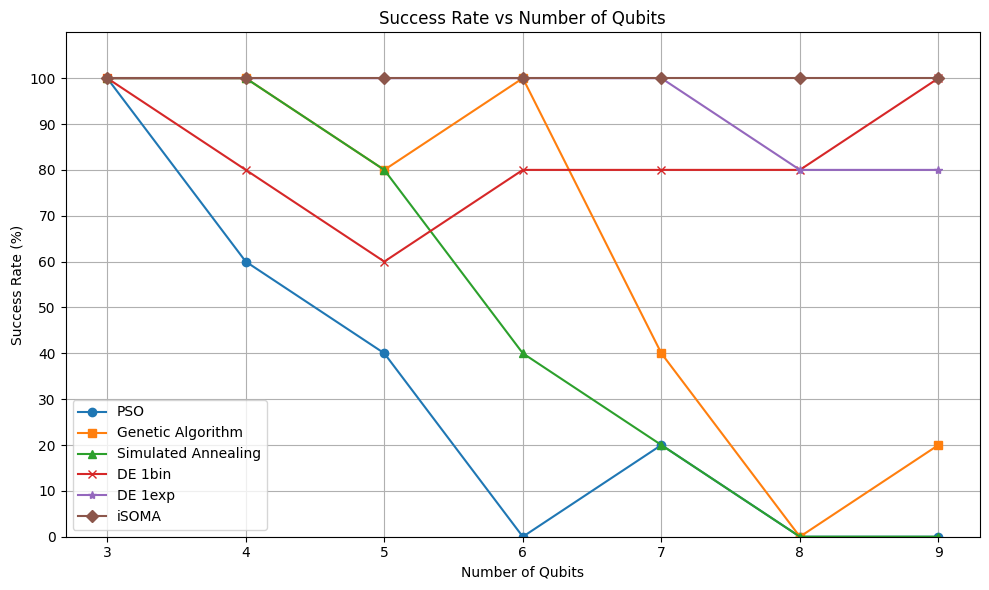

In [6]:
import matplotlib.pyplot as plt

# PSO data
pso_number_of_qubits = [3, 4, 5, 6, 7, 8, 9]
pso_success_rate = [100.0, 60.0, 40.0, 0.0, 20.0, 0.0, 0.0]

#DE 1bin
DE_number_of_qubits = [3, 4, 5, 6, 7, 8, 9]
DEbin_success_rate = [100.0, 80.0, 60.0, 80.0, 80.0, 80.0, 100.0]

#DE 1exp
DE_number_of_qubits = [3, 4, 5, 6, 7, 8, 9]
DEexp_success_rate = [100.0, 100.0, 100.0, 100.0, 100.0, 80.0, 80.0]
# Genetic Algorithm data
ga_number_of_qubits = [3, 4, 5, 6, 7, 8, 9]
ga_success_rate = [100.0, 100.0, 80.0, 100.0, 40.0, 0.0, 20.0]

# Simulated Annealing data
sa_number_of_qubits = [3, 4, 5, 6, 7, 8, 9]
sa_success_rate = [100.0, 100.0, 80.0, 40.0, 20.0, 0.0, 0.0]

# iSOMA
sa_number_of_qubits = [3, 4, 5, 6, 7, 8, 9]
iSOMA_success_rate = [100.0, 100.0, 100.0, 100.0, 100.0, 100, 100.0]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(pso_number_of_qubits, pso_success_rate, marker='o', linestyle='-', label='PSO')
plt.plot(ga_number_of_qubits, ga_success_rate, marker='s', linestyle='-', label='Genetic Algorithm')
plt.plot(sa_number_of_qubits, sa_success_rate, marker='^', linestyle='-', label='Simulated Annealing')
plt.plot(sa_number_of_qubits, DEbin_success_rate, marker='x', linestyle='-', label='DE 1bin')
plt.plot(sa_number_of_qubits, DEexp_success_rate, marker='*', linestyle='-', label='DE 1exp')
plt.plot(sa_number_of_qubits, iSOMA_success_rate, marker='D', linestyle='-', label='iSOMA')

plt.title('Success Rate vs Number of Qubits')
plt.xlabel('Number of Qubits')
plt.ylabel('Success Rate (%)')
plt.grid(True)
plt.xticks(range(3, 10))  # Set x-axis ticks from 3 to 10
plt.yticks(range(0, 101, 10))  # Set y-axis ticks from 0 to 100 with step 10
plt.ylim(0, 110)  # Set y-axis limit slightly above 100 for better visualization
plt.legend()
plt.tight_layout()
plt.show()


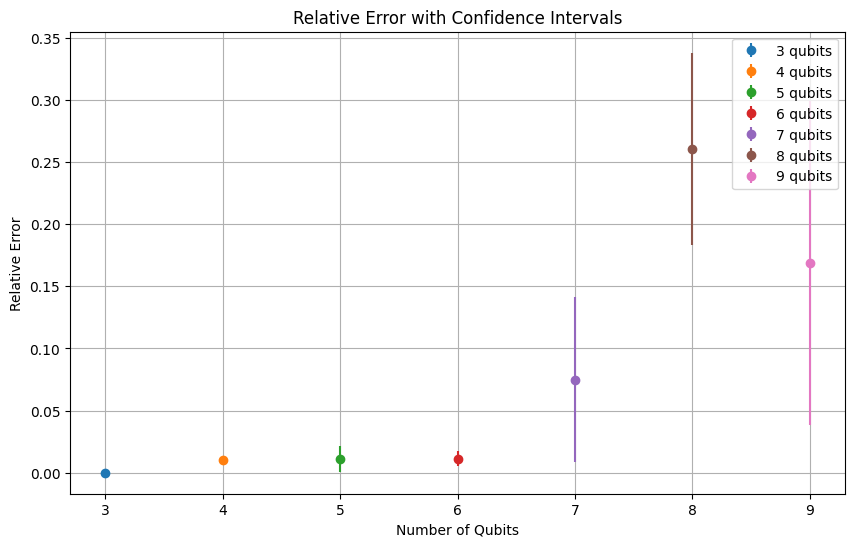

In [7]:
#simulated annealing
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

best_evaluations = np.array([[-2.0, -2.0, -2.0, -2.0, -2.0],
                             [-2.96875, -2.96875, -2.96875, -2.96875, -2.96875],
                             [-3.875, -3.96875, -3.96875, -3.96875, -4.0],
                             [-4.90625, -4.96875, -4.96875, -4.90625, -4.96875],
                             [-5.90625, -5.40625, -5.96875, -5.625, -4.84375],
                             [-4.9375, -5.78125, -4.78125, -4.5, -5.875],
                             [-6.78125, -7.5625, -5.09375, -5.84375, -7.96875]])
number_of_qubits = [3, 4, 5, 6, 7, 8, 9]

ground_energies = -np.array(number_of_qubits) + 1

relative_errors = np.abs(1 - best_evaluations / ground_energies[:, np.newaxis])

# Calculate confidence intervals (assuming normal distribution)
confidence_intervals = stats.norm.ppf(0.975) * np.std(relative_errors, ddof=1, axis=1) / np.sqrt(relative_errors.shape[1])

plt.figure(figsize=(10, 6))

for i in range(len(number_of_qubits)):
    plt.errorbar(number_of_qubits[i], np.mean(relative_errors[i]), yerr=confidence_intervals[i], fmt='o', label=f'{number_of_qubits[i]} qubits')

plt.xlabel('Number of Qubits')
plt.ylabel('Relative Error')
plt.title('Relative Error with Confidence Intervals')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# Define the data
data = [
    [3, 2.842600107, -1.96875],
    [3, 3.061155796, -1.96875],
    [3, 2.896158218, -1.96875],
    [3, 2.596779823, -2],
    [3, 4.111950636, -2],
    [4, 7.507912874, -2.96875],
    [4, 7.323825598, -2.9375],
    [4, 12.50368714, -3],
    [4, 8.169285774, -2.5625],
    [4, 4.045334339, -2.96875],
    [5, 17.20930362, -3.9375],
    [5, 13.75111151, -3.875],
    [5, 11.44472671, -4],
    [5, 14.92418623, -3.5625],
    [5, 8.318628788, -3.96875],
    [6, 26.31789613, -4.96875],
    [6, 11.71613741, -4.5625],
    [6, 49.14690423, -4.9375],
    [6, 23.14416432, -4.96875],
    [6, 25.5920043, -4.96875],
    [7, 40.02671766, -5.9375],
    [7, 27.84224343, -5.96875],
    [7, 75.39936328, -6],
    [7, 75.75840139, -5.5625],
    [7, 29.44248676, -5.96875],
    [8, 144.7130892, -6.96875],
    [8, 74.44028544, -6.96875],
    [8, 96.43358755, -6.5625],
    [8, 32.8809793, -6.96875],
    [8, 38.98316789, -6.96875],
    [9, 106.5436566, -7.96875],
    [9, 43.92754984, -7.96875],
    [9, 89.10233951, -7.96875],
    [9, 95.65417862, -7.96875],
    [9, 90.66462207, -7.96875]
]

# Dictionary to store success counts and total evaluations for each qubit
success_count = {}
total_evaluations = {}

# Iterate through the data to compute success counts and total evaluations for each qubit
for row in data:
    qubit = row[0]
    energy = row[2]
    success = abs(energy + qubit - 1) < 1e-1
    if qubit not in success_count:
        success_count[qubit] = 0
        total_evaluations[qubit] = 0
    total_evaluations[qubit] += 1
    if success:
        success_count[qubit] += 1

# Calculate success rate for each qubit
success_rates = {}
for qubit in success_count:
    success_rates[qubit] = (success_count[qubit] / total_evaluations[qubit]) * 100

# Print success rates
for qubit, rate in success_rates.items():
    print(f"Qubit {qubit}: Success Rate = {rate:.2f}%")


Qubit 3: Success Rate = 100.00%
Qubit 4: Success Rate = 80.00%
Qubit 5: Success Rate = 60.00%
Qubit 6: Success Rate = 80.00%
Qubit 7: Success Rate = 80.00%
Qubit 8: Success Rate = 80.00%
Qubit 9: Success Rate = 100.00%


In [24]:
# Define the data
data = [
    [3, 15.17803073, -2],
    [3, 52.41934514, -2],
    [3, 19.35330009, -2],
    [3, 52.07255721, -2],
    [3, 52.19670343, -2],
    [4, 78.11712241, -2.96875],
    [4, 78.18792725, -2.96875],
    [4, 78.50134802, -2.96875],
    [4, 78.61215043, -2.96875],
    [4, 79.16762614, -2.96875],
    [5, 109.5202911, -3.96875],
    [5, 108.9824612, -3.96875],
    [5, 109.0949996, -3.96875],
    [5, 110.9569867, -3.96875],
    [5, 110.529037, -3.96875],
    [6, 145.5582376, -4.96875],
    [6, 146.7409649, -4.96875],
    [6, 146.4112487, -4.96875],
    [6, 146.5297682, -4.96875],
    [6, 145.9585884, -4.96875],
    [7, 184.9822569, -5.96875],
    [7, 184.2789218, -5.96875],
    [7, 184.6354005, -5.9375],
    [7, 187.3874872, -5.96875],
    [7, 191.2514813, -5.96875],
    [8, 241.5592971, -6.875],
    [8, 244.4615681, -6.9375],
    [8, 241.21401, -6.9375],
    [8, 241.1864524, -6.96875],
    [8, 242.0533316, -6.96875],
    [9, 286.2099164, -7.78125],
    [9, 257.9076357, -7.84375],
    [9, 266.7499945, -7.78125],
    [9, 263.8224618, -7.78125],
    [9, 264.3548543, -7.84375]
]

# Dictionary to store success counts and total evaluations for each qubit
success_count = {}
total_evaluations = {}

# Iterate through the data to compute success counts and total evaluations for each qubit
for row in data:
    qubit = row[0]
    energy = row[2]
    success = abs(energy + qubit - 1) < 1e-1
    if qubit not in success_count:
        success_count[qubit] = 0
        total_evaluations[qubit] = 0
    total_evaluations[qubit] += 1
    if success:
        success_count[qubit] += 1

# Calculate success rate for each qubit
success_rates = {}
for qubit in success_count:
    success_rates[qubit] = (success_count[qubit] / total_evaluations[qubit]) * 100

# Print success rates
for qubit, rate in success_rates.items():
    print(f"Qubit {qubit}: Success Rate = {rate:.2f}%")


Qubit 3: Success Rate = 100.00%
Qubit 4: Success Rate = 100.00%
Qubit 5: Success Rate = 100.00%
Qubit 6: Success Rate = 100.00%
Qubit 7: Success Rate = 100.00%
Qubit 8: Success Rate = 80.00%
Qubit 9: Success Rate = 0.00%
